SOFTMAX on MNIST dataset

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [19]:
# loading MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int32)

X /= 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# convert everything to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# one-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (56000, 784)
Test data shape: (14000, 784)


In [20]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n_samples = y_pred.shape[0]
    log_likelihood = -np.log(y_pred[range(n_samples), y_true.argmax(axis=1)])
    loss = np.sum(log_likelihood) / n_samples
    return loss

def softmax_gradient(y_pred, y_true):
    return y_pred - y_true

In [21]:
input_size = 784  # 28x28 pixels
output_size = 10  
lr = 0.01
epochs = 300

W = np.random.randn(input_size, output_size) * 0.01
b = np.zeros((1, output_size))

In [22]:
# training loop
for epoch in range(epochs):
    # forward pass
    z = np.dot(X_train, W) + b
    y_pred = softmax(z)
    
    loss = cross_entropy_loss(y_pred, y_train_onehot)
    
    # backward pass
    dz = softmax_gradient(y_pred, y_train_onehot)
    dW = np.dot(X_train.T, dz) / X_train.shape[0]
    db = np.sum(dz, axis=0, keepdims=True) / X_train.shape[0]
    
    # update parameters
    W -= lr * dW
    b -= lr * db
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 10/300, Loss: 2.2232
Epoch 20/300, Loss: 2.1261
Epoch 30/300, Loss: 2.0363
Epoch 40/300, Loss: 1.9529
Epoch 50/300, Loss: 1.8756
Epoch 60/300, Loss: 1.8039
Epoch 70/300, Loss: 1.7374
Epoch 80/300, Loss: 1.6756
Epoch 90/300, Loss: 1.6184
Epoch 100/300, Loss: 1.5652
Epoch 110/300, Loss: 1.5158
Epoch 120/300, Loss: 1.4699
Epoch 130/300, Loss: 1.4272
Epoch 140/300, Loss: 1.3875
Epoch 150/300, Loss: 1.3504
Epoch 160/300, Loss: 1.3157
Epoch 170/300, Loss: 1.2833
Epoch 180/300, Loss: 1.2530
Epoch 190/300, Loss: 1.2246
Epoch 200/300, Loss: 1.1979
Epoch 210/300, Loss: 1.1727
Epoch 220/300, Loss: 1.1491
Epoch 230/300, Loss: 1.1268
Epoch 240/300, Loss: 1.1057
Epoch 250/300, Loss: 1.0858
Epoch 260/300, Loss: 1.0669
Epoch 270/300, Loss: 1.0490
Epoch 280/300, Loss: 1.0320
Epoch 290/300, Loss: 1.0159
Epoch 300/300, Loss: 1.0005


Test Accuracy: 82.32%


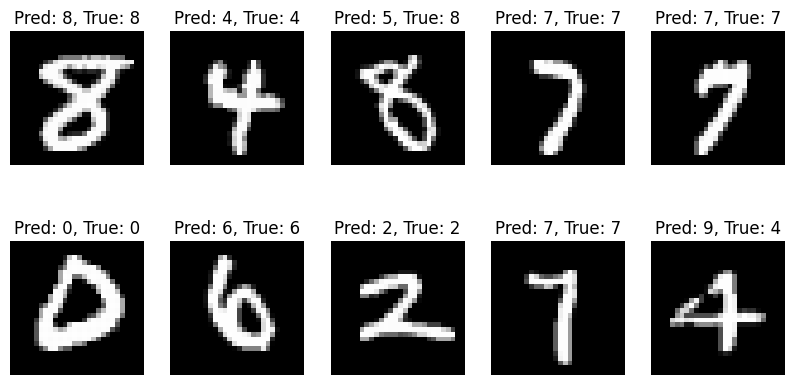

In [24]:
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
predictions = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

accuracy = np.mean(predictions == true_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {predictions[i]}, True: {true_labels[i]}")
    ax.axis('off')
plt.show()

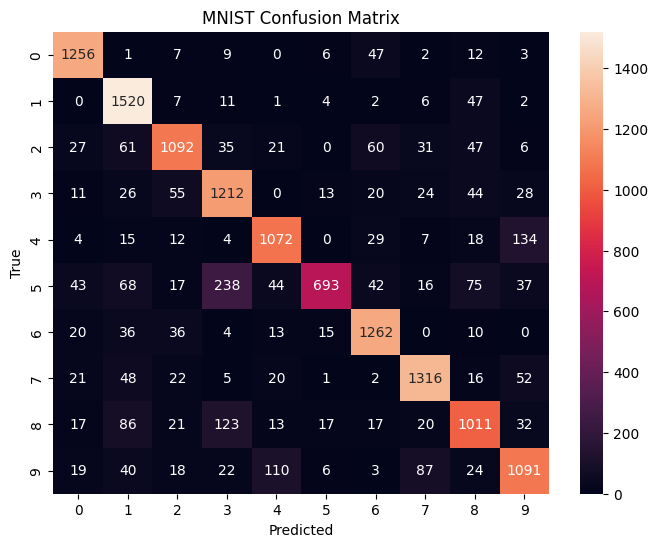


Classification report:
              precision    recall  f1-score   support

           0      0.886     0.935     0.910      1343
           1      0.800     0.950     0.868      1600
           2      0.848     0.791     0.819      1380
           3      0.729     0.846     0.783      1433
           4      0.828     0.828     0.828      1295
           5      0.918     0.544     0.683      1273
           6      0.850     0.904     0.876      1396
           7      0.872     0.876     0.874      1503
           8      0.775     0.745     0.760      1357
           9      0.788     0.768     0.778      1420

    accuracy                          0.823     14000
   macro avg      0.829     0.819     0.818     14000
weighted avg      0.828     0.823     0.820     14000



In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix")
plt.show()

print("\nClassification report:")
print(classification_report(y_test, predictions, digits=3))

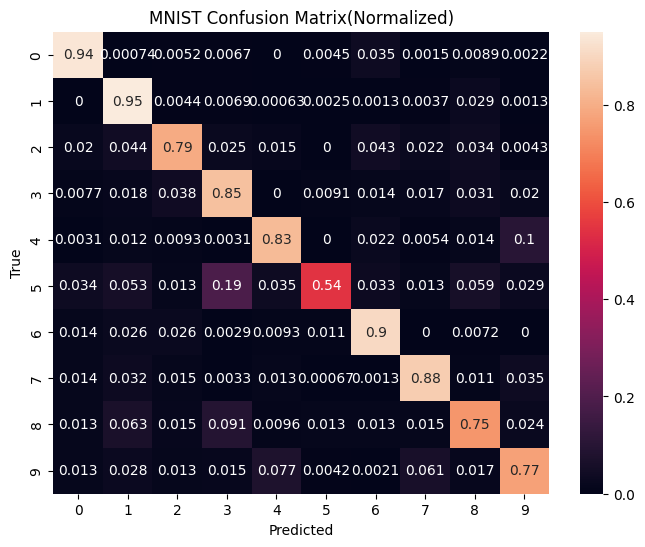

In [26]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix(Normalized)")
plt.show()

In [27]:
def tolerant_accuracy(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) <= 1)

print("Tolerant accuracy:", tolerant_accuracy(y_test, predictions))

Tolerant accuracy: 0.8487857142857143


Number of misclassified samples: 2475


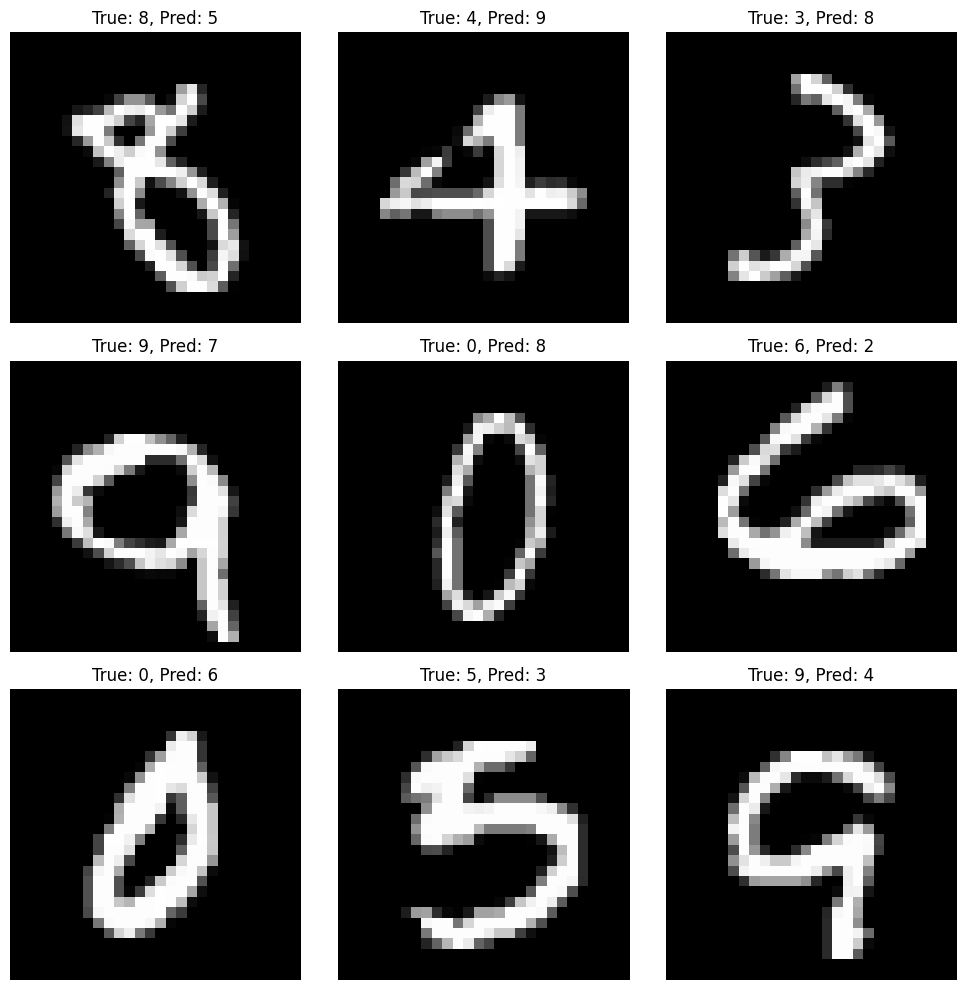

In [28]:
misclassified = np.where(predictions != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified)}")

plt.figure(figsize=(10,10))

for i in range(9):
    idx = misclassified[i]
    
    image = X_test[idx].reshape(28, 28)

    plt.subplot(3, 3, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {predictions[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
